# Density Match Evaluation for Different Parameterization Types

Compares different parameterization types and their fit to the true conditional X-U density.

## Parameterization Types

### Polynomial Baselines

- Deterministic polynomial parameterization
- Stochastic polynomial parameterization with AR(1) noise

### Bayesian Method

- Bayesian polynomial parameterization

### Flow-Based Parameterizations

- **Flow**: standard normalizing flow
- **Flow Base AR1**: normalizing flow with AR1 base distribution
- **Forcing flow**: conditioning includes external forcing
- **Tail flow**: normalizing flow with flexible tails (Hickling and Prangle, 2025: https://openreview.net/forum?id=Z6RsbHAJk5)
- **History flow**: conditioning includes state history
  

In [1]:
%autoreload

In [2]:
import sys
from pathlib import Path

# resolve project root (two levels up from this notebook)
PROJECT_ROOT = Path.cwd().resolve().parents[1]

SRC_DIR = PROJECT_ROOT / "src"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for p in (SRC_DIR, NOTEBOOKS_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import numpy.polynomial.polynomial as poly
import seaborn as sns
import torch
import yaml
from matplotlib.lines import Line2D

from models.forcing_schedule import forcing_at_array
from models.storage import load_output_l96
from notebook_utils import generate_sweep_dict_list
from parameterization.flow.flow_model import ConditionalRealNVP
from parameterization.flow.storage import load_checkpoint
from parameterization.flow.training.data import full_step_stride
from parameterization.utils.helpers import compute_coupling_from_x
from parameterization.utils.storage import (
    load_ar_p_parameters,
    load_bayesian_poly_coefficients,
    load_poly_coefficients,
)
from utils.config import ConfigFlowTraining, ConfigL96, ConfigParamsFit
from utils.sweep_utils import get_sweep_name


In [4]:
results_dir = PROJECT_ROOT / "results"

flow_variation_dirs = [
    results_dir / "parameters_flow",
    results_dir / "parameters_ar_base_flow",
    results_dir / "parameters_forcing_flow",
    results_dir / "parameters_history_flow",
    results_dir / "parameters_tail_flow",
]

params_dir = results_dir / "fitted_parameters"
training_data_dir = results_dir / "l96_training_data_t20000"

output_subdir = ""
paper_figures_dir = (
    PROJECT_ROOT / "paper" / output_subdir / "figures" / "density_match_evaluation"
)
paper_figures_dir.mkdir(parents=True, exist_ok=True)

TEST_PERC = 0.75

## Load data


In [5]:
def load_yaml(file_path):
    with open(file_path, "r") as f:
        return yaml.safe_load(f)

In [6]:
def _get_config_path(dir, config_str):
    # Find config_str in this directory (non-recursive).
    matches = sorted(dir.glob(config_str))
    if len(matches) == 0:
        raise FileNotFoundError(f"No {config_str} found in {dir}")
    if len(matches) > 1:
        print(f"Warning: Multiple {config_str} files found in {dir}: {matches}")
    config_path = matches[0]
    return config_path

In [9]:
params_dict = {}
DEFAULT_SWEEP_KEY = "default"

for model_dir in flow_variation_dirs:
    # Flow model
    print(f"Processing model directory: {model_dir.name}")
    sweep_path = model_dir / "sweep.yaml"
    sweep = load_yaml(sweep_path)

    for s in generate_sweep_dict_list(sweep):
        sweep_name = get_sweep_name(s)
        out_path = model_dir / sweep_name

        config_path = out_path / "config.yaml"
        config = ConfigFlowTraining(config_path)

        model, _ = load_checkpoint(
            config.output_dir(out_path), model_cls=ConditionalRealNVP
        )

        sweep_key = sweep_name if sweep_name != "" else DEFAULT_SWEEP_KEY
        params_dict[(model_dir.name, sweep_key)] = {"config": config}
        params_dict[(model_dir.name, sweep_key)] = {"model": model}

        name = model_dir.name.lower()
        if "forcing" in name:
            params_dict[(model_dir.name, sweep_key)]["F"] = config.f_schedule.F
        if "history" in name:
            delta_t = config.delta_t
            si = config.si
            params_dict[(model_dir.name, sweep_key)]["delta_t"] = delta_t
            params_dict[(model_dir.name, sweep_key)]["stride"] = full_step_stride(
                config.si, config.dt_full
            )

        if TEST_PERC != config.test_perc:
            print(
                f"Warning: Using different test_perc value: sweep config ({config.test_perc}) vs. global TEST_PERC ({TEST_PERC})."
            )


Processing model directory: parameters_flow
Processing model directory: parameters_ar_base_flow
Processing model directory: parameters_forcing_flow
Processing model directory: parameters_history_flow
Processing model directory: parameters_tail_flow


In [10]:
# Baseline parameterizations
cfg_names = ["fit_params_baseline*.yaml", "fit_params_bayes*.yaml"]


for cfg_name in cfg_names:
    # if "bayes" in cfg_name:
    #     print(f"Skipping Bayesian parameterization config: {cfg_name}")
    #     continue
    config_path = _get_config_path(params_dir, cfg_name)
    config = ConfigParamsFit(config_path, eval_mode=True)

    if "baseline" in cfg_name:
        params_dir_key = params_dir.name + "_baseline"

        params_dict[(params_dir_key + "_coefs", DEFAULT_SWEEP_KEY)] = {
            "config": config,
        }

        coefs = load_poly_coefficients(config.coefs_dir(params_dir))
        params_dict[(params_dir_key + "_coefs", DEFAULT_SWEEP_KEY)]["coefs"] = coefs

        ar_orders = config.ar_order
        if not isinstance(ar_orders, list):
            ar_orders = [ar_orders]

        for p in ar_orders:
            params_dict[(params_dir_key + f"_ar_p-{p}", DEFAULT_SWEEP_KEY)] = {
                "config": config,
            }

            rho, sigma = load_ar_p_parameters(
                config.ar_parameters_dir(params_dir), ar_order=p
            )
            params_dict[(params_dir_key + f"_ar_p-{p}", DEFAULT_SWEEP_KEY)]["rho"] = rho
            params_dict[(params_dir_key + f"_ar_p-{p}", DEFAULT_SWEEP_KEY)]["sigma"] = (
                sigma
            )

    else:
        params_dir_key = params_dir.name + "_bayes"
        params_dict[(params_dir_key, DEFAULT_SWEEP_KEY)] = {"config": config}
        bayesian_coefs = load_bayesian_poly_coefficients(config.coefs_dir(params_dir))
        params_dict[(params_dir_key, DEFAULT_SWEEP_KEY)]["bayesian_coefs"] = (
            bayesian_coefs
        )


In [11]:
for k, v in params_dict.items():
    print(f"{k}: {list(v.keys())}")

('parameters_flow', 'default'): ['model']
('parameters_ar_base_flow', 'default'): ['model']
('parameters_forcing_flow', 'default'): ['model', 'F']
('parameters_history_flow', 'delta_t_1'): ['model', 'delta_t', 'stride']
('parameters_history_flow', 'delta_t_2'): ['model', 'delta_t', 'stride']
('parameters_tail_flow', 'default'): ['model']
('fitted_parameters_baseline_coefs', 'default'): ['config', 'coefs']
('fitted_parameters_baseline_ar_p-1', 'default'): ['config', 'rho', 'sigma']
('fitted_parameters_bayes', 'default'): ['config', 'bayesian_coefs']


In [13]:
config_path = training_data_dir / "F_20.0" / "config.yaml"
l96_config = ConfigL96(config_path)

x, _, t = load_output_l96(
    training_data_dir / "F_20.0" / "l96",
    backend=l96_config.load_backend,
)
if l96_config.load_backend == "zarr":
    x = np.asarray(x)

# Compute coupling term from X
F_values = forcing_at_array(l96_config.f_schedule, t)
u, x = compute_coupling_from_x(
    x, l96_config.si, F_values, l96_config.h, l96_config.b, l96_config.c
)

test_index = int((1 - TEST_PERC) * x.shape[0])
x_test = x[test_index:]
u_test = u[test_index:]


## Sample
This may take some while

In [14]:
def _to_numpy(a):
    if torch.is_tensor(a):
        return a.detach().cpu().numpy()
    return np.asarray(a, dtype=np.float32)

In [15]:
t0_global = 0
u_sample_flow = {}
t0_by_model = {}

for model_key, model_dict in params_dict.items():
    name = model_key[0].lower()
    if "flow" not in name:
        continue

    print(f"Sampling {model_key}...")

    model = params_dict[model_key]["model"]

    x_t = _to_numpy(x_test)
    # make tensor
    x_test_t = x_t if torch.is_tensor(x_t) else torch.as_tensor(x_t)

    # match device + dtype to model
    p = next(model.parameters())
    x_test_t = x_test_t.to(device=p.device, dtype=p.dtype)

    model.eval()
    t0 = 0

    with torch.no_grad():
        # ---------- conditioning ----------
        if "forcing" in name:
            # cond = [x, F]
            F = params_dict[model_key]["F"]

            F_t = torch.full(
                (x_test_t.shape[0], 1),
                float(F),
                device=x_test_t.device,
                dtype=x_test_t.dtype,
            )
            cond = torch.cat([x_test_t, F_t], dim=-1)

        elif "history" in name:
            delta_t = int(params_dict[model_key]["delta_t"])  # number of full steps
            stride = int(params_dict[model_key]["stride"])  # samples per full step

            if delta_t == 0:
                cond = x_test_t
                t0 = 0
            else:
                T, K = x_test_t.shape
                lag_steps = delta_t * stride  # samples back to reach delta_t full steps
                if T <= lag_steps:
                    raise ValueError(
                        f"Need T > delta_t*stride. Got T={T}, delta_t={delta_t}, stride={stride}."
                    )

                # only evaluate where history is fully available (no padding)
                t0 = lag_steps
                t0_global = max(t0_global, t0)

                # blocks for [x_t, x_{t-stride}, x_{t-2*stride}, ..., x_{t-delta_t*stride}]
                blocks = []
                for j in range(delta_t + 1):
                    lag = j * stride
                    blocks.append(x_test_t[t0 - lag : T - lag])  # (T-t0, K)

                cond = torch.cat(blocks, dim=-1)  # (T-t0, K*(delta_t+1))

        else:
            # base flow + tail flow
            cond = x_test_t

        if "ar_base" in name:
            cond_seq = cond.unsqueeze(0)  # (1,T,cond_dim)
            T = cond_seq.shape[1]
            W = 2048  # must be <= model.max_len
            outs = []
            for s in range(0, T, W):
                c = cond_seq[:, s : s + W, :]
                outs.append(model.sample_seq(cond=c).squeeze(0).cpu().numpy())
            u_samp = np.concatenate(outs, axis=0)
        else:
            # cond: (T, cond_dim)  -> cond_seq: (1, T, cond_dim)
            cond_seq = cond.unsqueeze(0)
            u_samp = (
                model.sample_seq(cond=cond_seq).squeeze(0).detach().cpu().numpy()
            )  # (T, u_dim)

    u_sample_flow[model_key] = u_samp
    t0_by_model[model_key] = t0
    del cond
print("Done.")

Sampling ('parameters_flow', 'default')...
Sampling ('parameters_ar_base_flow', 'default')...
Sampling ('parameters_forcing_flow', 'default')...
Sampling ('parameters_history_flow', 'delta_t_1')...
Sampling ('parameters_history_flow', 'delta_t_2')...
Sampling ('parameters_tail_flow', 'default')...
Done.


In [16]:
# Align all samples to the same t0_global (the maximum t0 across all models) by trimming the beginning of the sample arrays as needed
for k, u in u_sample_flow.items():
    t0 = t0_by_model[k]
    offset = max(0, t0_global - t0)
    u_sample_flow[k] = u[offset:]
x_test = x_test[t0_global:]
u_test = u_test[t0_global:]


## Plot X-U density match for all parameterizations


In [17]:
def _parse_params_id(params_key):
    params_id = params_key[0]
    sweep_key = params_key[1]
    if params_id.startswith("parameters_flow"):
        return "Flow"
    if params_id.startswith("parameters_ar_base_flow"):
        return "Base AR(1) Flow"
    elif params_id.startswith("parameters_forcing_flow"):
        return "Forcing Flow"
    elif params_id.startswith("parameters_history_flow"):
        if sweep_key == "delta_t_1":
            return r"History Flow ($\tau = 1$)"
        if sweep_key == "delta_t_2":
            return r"History Flow ($\tau = 2$)"
    elif params_id.startswith("parameters_tail_flow"):
        return "Tail Flow"
    elif params_id.startswith("fitted_parameters_baseline_coefs"):
        return "Polynomial Baseline"
    elif params_id.startswith("fitted_parameters_baseline_ar_p-1"):
        return "Polynomial + AR(1)"
    elif params_id.startswith("fitted_parameters_bayes"):
        return "Bayesian Regression"
    else:
        raise ValueError(f"Unknown params_id: {params_id}")


palette = sns.color_palette("colorblind")

COLOR_POLY = palette[4]  # purple
COLOR_AR1 = palette[1]  # orange
COLOR_BAYES = palette[6]  # pink/red

In [18]:
for k, v in params_dict.items():
    print(f"{k}: {list(v.keys())}")

u_sample_flow.keys()


('parameters_flow', 'default'): ['model']
('parameters_ar_base_flow', 'default'): ['model']
('parameters_forcing_flow', 'default'): ['model', 'F']
('parameters_history_flow', 'delta_t_1'): ['model', 'delta_t', 'stride']
('parameters_history_flow', 'delta_t_2'): ['model', 'delta_t', 'stride']
('parameters_tail_flow', 'default'): ['model']
('fitted_parameters_baseline_coefs', 'default'): ['config', 'coefs']
('fitted_parameters_baseline_ar_p-1', 'default'): ['config', 'rho', 'sigma']
('fitted_parameters_bayes', 'default'): ['config', 'bayesian_coefs']


dict_keys([('parameters_flow', 'default'), ('parameters_ar_base_flow', 'default'), ('parameters_forcing_flow', 'default'), ('parameters_history_flow', 'delta_t_1'), ('parameters_history_flow', 'delta_t_2'), ('parameters_tail_flow', 'default')])

In [19]:
FLOW_ORDER = [
    "parameters_flow",
    "parameters_history_flow",
    "parameters_ar_base_flow",
    "parameters_tail_flow",
]

# Build rank map (exactly as written)
flow_rank = {name: i for i, name in enumerate(FLOW_ORDER)}


def sort_key(k):
    first, second = k

    rank = next(
        (flow_rank[name] for name in FLOW_ORDER if first.startswith(name)), float("inf")
    )

    return (rank, second)

In [20]:
def get_param_params_keys(params_dict, skip_bayes=False):
    params_keys = list(params_dict.keys())
    flow_keys = [k for k in params_keys if "flow" in k[0]]

    k_poly = [k for k in params_keys if "baseline_coefs" in k[0]]
    if len(k_poly) == 1:
        k_poly = k_poly[0]
    else:
        raise ValueError(f"Expected exactly one key for baseline coefs, found {k_poly}")
    k_ar1 = [k for k in params_keys if "baseline_ar_p" in k[0]]
    if len(k_ar1) == 1:
        k_ar1 = k_ar1[0]
    else:
        raise ValueError(f"Expected exactly one key for baseline ar1, found {k_ar1}")
    if skip_bayes:
        return k_poly, k_ar1, flow_keys

    k_bayes = [k for k in params_keys if "bayes" in k[0]]
    if len(k_bayes) == 1:
        k_bayes = k_bayes[0]
    else:
        raise ValueError(f"Expected exactly one key for bayes, found {k_bayes}")

    return k_poly, k_ar1, k_bayes, flow_keys

In [21]:
def _style(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)
    ax.tick_params(direction="out", bottom=True, left=True)


def _hist2d(ax, x, u, xedges, yedges, cmap):
    h = ax.hist2d(
        np.asarray(x).reshape(-1),
        np.asarray(u).reshape(-1),
        bins=[xedges, yedges],
        density=True,
        cmap=cmap,
        rasterized=True,
    )
    im = h[3]
    im.set_array(np.ma.masked_where(im.get_array() == 0, im.get_array()))
    return im


def _contour(ax, H, xedges, yedges, contour_levels):
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    Xc, Yc = np.meshgrid(xc, yc, indexing="xy")

    Z = H.T  # (y, x)
    Zm = ma.masked_where(Z <= 0, Z)

    cmap = sns.color_palette("YlOrRd", as_cmap=True)

    ax.contour(
        Xc,
        Yc,
        Zm,
        levels=contour_levels,
        cmap=cmap,
        linewidths=0.9,
        alpha=0.9,
    )


def _as_u_samp(obj):
    """
    Helper: accept either a dict with 'u_samp' or a raw array.
    """
    if isinstance(obj, dict) and "u_samp" in obj:
        return obj["u_samp"]
    return obj


## Paper read plot for density match and difference

In [22]:
TEXT_WIDTH = 6.75


# scaling is currently not used
def scaled_fontsize(fontsize, figsize_width, which_base_width):
    if which_base_width == "text":
        base_width = TEXT_WIDTH * 1.2
    elif which_base_width == "column":
        base_width = TEXT_WIDTH
    else:
        raise ValueError(f"Unexpected which_base_width: {which_base_width}")
    scale = figsize_width / base_width
    return fontsize * scale

In [23]:
def plot_parameter_fit_paper_ready_combined(
    params_dict,
    x,
    u_true,
    u_sample_flow,
    bins=40,
    add_contours=False,
    contour_levels=6,
    flow_models_to_plot=None,
    figsize=(12, 10),
    ncols=5,
    which_base_width="text",
    cb_only_once=True,  # only show colorbar for two rows
):
    # do not use scaling here but hardcode font sizes (scaling seems to be tricky here)
    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 10,
        },
    )

    # ------------------------- setup keys -------------------------
    k_poly, k_ar1, k_bayes, flow_keys = get_param_params_keys(params_dict)

    if flow_models_to_plot is None:
        flow_keys_sel = list(flow_keys)
    else:
        wanted = set(flow_models_to_plot)
        flow_keys_sel = []
        for k in flow_keys:
            params_id = k[0]
            if k in wanted or params_id in wanted:
                flow_keys_sel.append(k)

    flow_keys_sel = sorted(flow_keys_sel, key=sort_key)
    flow_panels = [(k, _parse_params_id(k)) for k in flow_keys_sel]
    for flow_key, _ in flow_panels:
        if flow_key not in u_sample_flow:
            raise KeyError(f"u_sample_flow missing required key: {flow_key}")

    # ------------------------- data / binning -------------------------
    x = np.asarray(x).reshape(-1)
    u_true = np.asarray(u_true).reshape(-1)

    cmap_pdf = plt.cm.viridis.copy()
    cmap_pdf.set_bad("white")

    H_true, xedges, yedges = np.histogram2d(x, u_true, bins=bins, density=True)
    xs = np.linspace(xedges[0], xedges[-1], 400)

    coefs = np.asarray(params_dict[k_poly]["coefs"])
    y_poly = poly.polyval(xs, coefs)

    rho = float(params_dict[k_ar1]["rho"])
    sigma_i = float(params_dict[k_ar1]["sigma"])
    sigma_e = np.sqrt(sigma_i**2 / (1 - rho**2))

    bayes_coefs = np.asarray(params_dict[k_bayes]["bayesian_coefs"])

    # ------------------------- precompute diffs + vmax -------------------------
    diffs = []
    vmax = 0.0
    for k, _title in flow_panels:
        u_flow = np.asarray(_as_u_samp(u_sample_flow[k])).reshape(-1)
        H_flow, _, _ = np.histogram2d(x, u_flow, bins=[xedges, yedges], density=True)
        Dmat = H_flow - H_true
        diffs.append(Dmat)
        vmax = max(vmax, float(np.nanmax(np.abs(Dmat))) if Dmat.size else 0.0)

    cmap_diff = plt.cm.RdBu_r.copy()
    cmap_diff.set_bad("white")

    # ------------------------- helpers -------------------------
    def _set_ticks_labels(ax, r, c, last_row):
        ax.set_xticks([-10, -5, 0, 5, 10, 15])
        ax.set_yticks([-10, 0, 10, 20])

        # y labels/ticks: only left-most column
        if c == 0:
            ax.set_ylabel(r"$U_k$")
            ax.tick_params(axis="y", left=True, labelleft=True, length=5)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", left=True, labelleft=False, length=3)

        # x labels/ticks: only bottom row
        if r == last_row:
            ax.set_xlabel(r"$X_k$")
            ax.tick_params(axis="x", bottom=True, labelbottom=True, length=5)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", bottom=True, labelbottom=False, length=3)

    # ------------------------- layout -------------------------
    # First 2x2 block: truth + fits, in fixed order:
    # (0,0) Truth
    # (1,0) Poly det baseline
    # (0,1) Poly+AR1
    # (1,1) Bayes
    #
    # Then flows: blocks of 2 rows:
    #   upper row: density (PDF)
    #   lower row: difference (model - truth)

    n_flows = len(flow_panels)

    # first row-pair already contains the fixed 2x2 block,
    # so only columns 2..ncols-1 are available there for flows
    first_block_capacity = max(ncols - 2, 0)
    # flows that do not fit into the first row-pair
    remaining_flows = max(0, n_flows - first_block_capacity)
    # each additional row-block has all ncols columns available
    extra_row_blocks = math.ceil(remaining_flows / ncols)
    # one initial row-block (rows 0/1) + any extra blocks
    n_row_blocks = 1 + extra_row_blocks
    # each block consists of two rows: PDF row + difference row
    n_rows = 2 * n_row_blocks
    last_row = n_rows - 1

    fig, axes = plt.subplots(
        n_rows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.asarray(axes)
    # remember used axes to hide the unused ones at the end
    used_axes = set()

    if axes.ndim == 1:  # happens if n_rows==1 or ncols==1
        if n_rows == 1 and ncols == 1:
            axes = axes.reshape(1, 1)
        elif n_rows == 1:
            axes = axes.reshape(1, ncols)
        else:
            axes = axes.reshape(n_rows, 1)

    # ---- first 2x2 block ----
    im_pdf_ref = None
    # (0,0) Truth
    ax = axes[0, 0]
    im_pdf_ref = _hist2d(ax, x, u_true, xedges, yedges, cmap_pdf)
    if add_contours:
        _contour(ax, H_true, xedges, yedges, contour_levels)
    ax.set_title("Truth")
    _style(ax)
    _set_ticks_labels(ax, 0, 0, last_row)

    # (1,0) Poly det baseline
    ax = axes[1, 0]
    _hist2d(ax, x, u_true, xedges, yedges, cmap_pdf)
    ax.plot(xs, y_poly, lw=1.8, color=COLOR_POLY, label="poly(X)")
    ax.legend(frameon=False, loc="lower right")
    if add_contours:
        _contour(ax, H_true, xedges, yedges, contour_levels)
    ax.set_title(f"{_parse_params_id(k_poly)}")
    _style(ax)
    _set_ticks_labels(ax, 1, 0, last_row)

    # (0,1) Poly+AR1
    ax = axes[0, 1]
    _hist2d(ax, x, u_true, xedges, yedges, cmap_pdf)

    ax.plot(xs, y_poly, lw=1.8, color=COLOR_AR1, label="poly(X)")
    ax.fill_between(
        xs,
        y_poly - sigma_e,
        y_poly + sigma_e,
        color=COLOR_AR1,
        alpha=0.5,
        label=r"poly(X) $\pm \sigma_e$",
    )
    ax.legend(frameon=False, loc="lower right")
    if add_contours:
        _contour(ax, H_true, xedges, yedges, contour_levels)
    ax.set_title(f"{_parse_params_id(k_ar1)}")
    _style(ax)
    _set_ticks_labels(ax, 0, 1, last_row)

    # (1,1) Bayes
    ax = axes[1, 1]
    _hist2d(ax, x, u_true, xedges, yedges, cmap_pdf)
    N, M, D = bayes_coefs.shape
    coefs_flat = bayes_coefs.reshape(N * M, D)
    for ii in range(coefs_flat.shape[0]):
        ax.plot(
            xs,
            poly.polyval(xs, coefs_flat[ii]),
            lw=0.9,
            color=COLOR_BAYES,
            alpha=0.35,
        )
    ax.legend(
        handles=[Line2D([0], [0], color=COLOR_BAYES, lw=1.5, label="poly$_i$(X)")],
        frameon=False,
        loc="lower right",
    )
    if add_contours:
        _contour(ax, H_true, xedges, yedges, contour_levels)
    ax.set_title(f"{_parse_params_id(k_bayes)}")
    _style(ax)
    _set_ticks_labels(ax, 1, 1, last_row)

    used_axes.update(
        {
            (0, 0),  # Truth
            (1, 0),  # Poly det baseline
            (0, 1),  # Poly+AR1
            (1, 1),  # Bayes
        }
    )

    # ---- flow blocks: density on upper row, diff on lower row ----
    im_diff_ref = None
    for j, ((k, title), Dmat) in enumerate(zip(flow_panels, diffs)):
        if j < first_block_capacity:
            row_block = 0
            c = j + 2
        else:
            j2 = j - first_block_capacity
            row_block = 1 + (j2 // ncols)
            c = j2 % ncols

        r_pdf = 2 * row_block
        r_diff = r_pdf + 1

        ax_pdf = axes[r_pdf, c]
        ax_diff = axes[r_diff, c]

        # Density (upper)
        u_flow = np.asarray(_as_u_samp(u_sample_flow[k])).reshape(-1)
        if add_contours:
            H_flow, _, _ = np.histogram2d(
                x, u_flow, bins=[xedges, yedges], density=True
            )
        _hist2d(ax_pdf, x, u_flow, xedges, yedges, cmap_pdf)
        if add_contours:
            _contour(ax_pdf, H_flow, xedges, yedges, contour_levels)
        ax_pdf.set_title(title)
        _style(ax_pdf)
        _set_ticks_labels(ax_pdf, r_pdf, c, last_row)

        # Difference (lower)
        im = ax_diff.imshow(
            ma.masked_where(Dmat == 0, Dmat).T,
            origin="lower",
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap=cmap_diff,
            vmin=-vmax,
            vmax=vmax,
            aspect="auto",
        )
        if im_diff_ref is None:
            im_diff_ref = im
        ax_diff.set_title(f"{title} − Truth")
        _style(ax_diff)
        _set_ticks_labels(ax_diff, r_diff, c, last_row)

        used_axes.add((r_pdf, c))
        used_axes.add((r_diff, c))

    # ---- turn off unused axes ----
    for r in range(n_rows):
        for c in range(ncols):
            if (r, c) not in used_axes:
                axes[r, c].axis("off")

    # ---- Colorbars ----
    # density: right-most axis in all row blocks
    # ---- Colorbars: one pair per 2-row block, always in the last column ----
    if ncols >= 1:
        for row_block in range(n_row_blocks):
            r_pdf = 2 * row_block
            r_diff = r_pdf + 1
            c_last = ncols - 1

            # PDF colorbar on the top row of this block
            if im_pdf_ref is not None:
                cbar_pdf = fig.colorbar(
                    im_pdf_ref,
                    ax=axes[r_pdf, c_last],
                    location="right",
                    pad=0.02,
                    fraction=0.05,
                )
                cbar_pdf.set_label("PDF")

            # diff colorbar on the bottom row of this block
            if im_diff_ref is not None:
                cbar_diff = fig.colorbar(
                    im_diff_ref,
                    ax=axes[r_diff, c_last],
                    location="right",
                    pad=0.02,
                    fraction=0.05,
                )
                cbar_diff.set_label(
                    r"$\mathrm{PDF}_{\mathrm{model}} - \mathrm{PDF}_{\mathrm{truth}}$"
                )
            if cb_only_once:
                break

    return fig

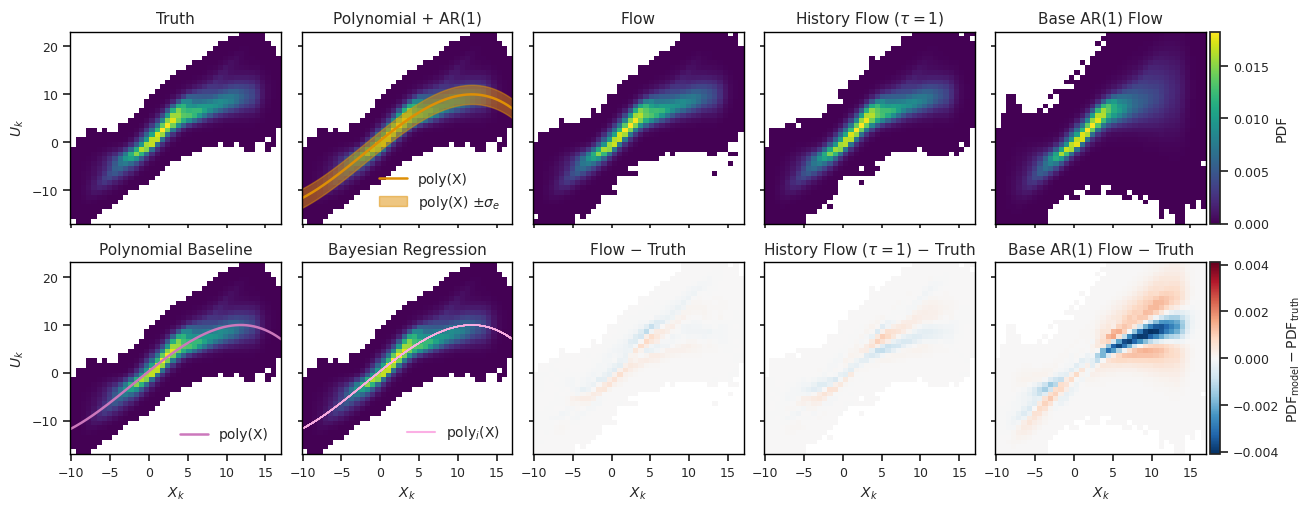

In [24]:
flows_to_plot = [
    ("parameters_flow", "default"),
    ("parameters_history_flow", "delta_t_1"),
    ("parameters_ar_base_flow", "default"),
]
show_contour_levels = False
fig = plot_parameter_fit_paper_ready_combined(
    params_dict,
    x_test,
    u_test,
    u_sample_flow,
    bins=40,
    add_contours=show_contour_levels,
    contour_levels=4,
    flow_models_to_plot=flows_to_plot,
    figsize=(13, 5),
    ncols=5,
    which_base_width="text",
)

plt.show()

fig.savefig(
    paper_figures_dir
    / f"xu_fit_with_difference_{show_contour_levels}_selected_flows.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)

plt.close()


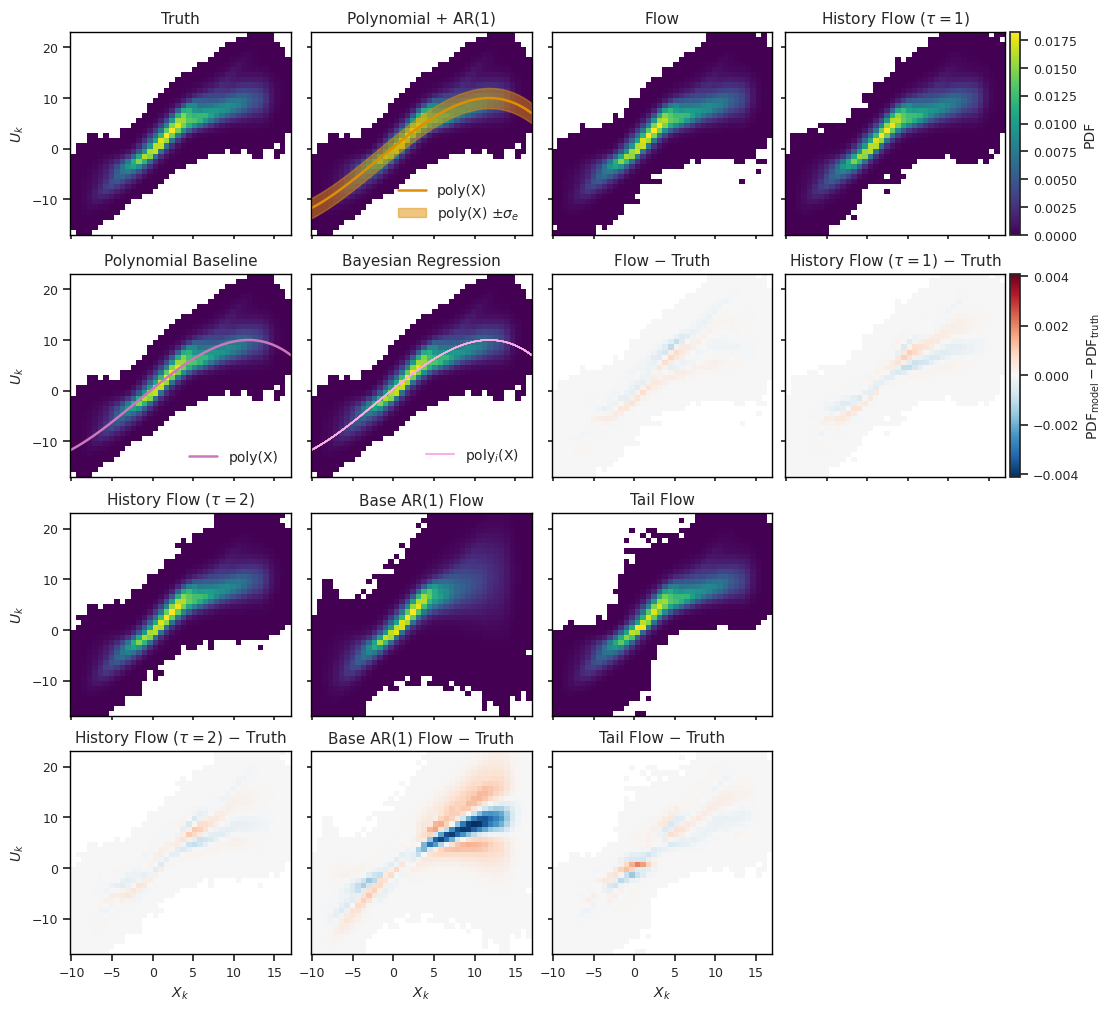

In [25]:
flows_to_plot = [
    ("parameters_flow", "default"),
    ("parameters_history_flow", "delta_t_1"),
    ("parameters_history_flow", "delta_t_2"),
    ("parameters_ar_base_flow", "default"),
    ("parameters_tail_flow", "default"),
]
show_contour_levels = False
fig = plot_parameter_fit_paper_ready_combined(
    params_dict,
    x_test,
    u_test,
    u_sample_flow,
    bins=40,
    add_contours=show_contour_levels,
    contour_levels=4,
    flow_models_to_plot=flows_to_plot,
    figsize=(11, 10),
    ncols=4,
)

plt.show()

fig.savefig(
    paper_figures_dir / f"xu_fit_with_difference_{show_contour_levels}.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)
plt.close()


#### Fixed 4 column layout

In [27]:
def plot_parameter_fit_paper_ready_combined_four_columns(
    params_dict,
    x,
    u_true,
    u_sample_flow,
    bins=40,
    add_contours=False,
    contour_levels=6,
    flow_models_to_plot=None,
    figsize=(12, 10),
    which_base_width="text",
):
    import math
    import numpy as np
    import numpy.ma as ma
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    import seaborn as sns
    from numpy.polynomial import polynomial as poly

    # fixed layout
    ncols = 4

    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 10,
        },
    )

    # ------------------------- setup keys -------------------------
    k_poly, k_ar1, k_bayes, flow_keys = get_param_params_keys(params_dict)

    if flow_models_to_plot is None:
        flow_keys_sel = list(flow_keys)
    else:
        wanted = set(flow_models_to_plot)
        flow_keys_sel = []
        for k in flow_keys:
            params_id = k[0]
            if k in wanted or params_id in wanted:
                flow_keys_sel.append(k)

    flow_keys_sel = sorted(flow_keys_sel, key=sort_key)
    flow_panels = [(k, _parse_params_id(k)) for k in flow_keys_sel]
    for flow_key, _ in flow_panels:
        if flow_key not in u_sample_flow:
            raise KeyError(f"u_sample_flow missing required key: {flow_key}")

    # ------------------------- data / binning -------------------------
    x = np.asarray(x).reshape(-1)
    u_true = np.asarray(u_true).reshape(-1)

    cmap_pdf = plt.cm.viridis.copy()
    cmap_pdf.set_bad("white")

    H_true, xedges, yedges = np.histogram2d(x, u_true, bins=bins, density=True)
    xs = np.linspace(xedges[0], xedges[-1], 400)

    coefs = np.asarray(params_dict[k_poly]["coefs"])
    y_poly = poly.polyval(xs, coefs)

    rho = float(params_dict[k_ar1]["rho"])
    sigma_i = float(params_dict[k_ar1]["sigma"])
    sigma_e = np.sqrt(sigma_i**2 / (1 - rho**2))

    bayes_coefs = np.asarray(params_dict[k_bayes]["bayesian_coefs"])

    # ------------------------- precompute diffs + vmax -------------------------
    diffs = []
    vmax = 0.0
    for k, _title in flow_panels:
        u_flow = np.asarray(_as_u_samp(u_sample_flow[k])).reshape(-1)
        H_flow, _, _ = np.histogram2d(x, u_flow, bins=[xedges, yedges], density=True)
        Dmat = H_flow - H_true
        diffs.append(Dmat)
        vmax = max(vmax, float(np.nanmax(np.abs(Dmat))) if Dmat.size else 0.0)

    cmap_diff = plt.cm.RdBu_r.copy()
    cmap_diff.set_bad("white")

    # ------------------------- helpers -------------------------
    n_flows = len(flow_panels)
    n_flow_rows = math.ceil(n_flows / 2)
    n_rows = 1 + n_flow_rows
    last_row = n_rows - 1

    def _set_ticks_labels(ax, r, c):
        ax.set_xticks([-10, -5, 0, 5, 10, 15])
        ax.set_yticks([-10, 0, 10, 20])

        # y labels only in left-most column
        if c == 0:
            ax.set_ylabel(r"$U_k$")
            ax.tick_params(axis="y", left=True, labelleft=True, length=5)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", left=True, labelleft=False, length=3)

        # x labels only in bottom row
        if r == last_row:
            ax.set_xlabel(r"$X_k$")
            ax.tick_params(axis="x", bottom=True, labelbottom=True, length=5)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", bottom=True, labelbottom=False, length=3)

    # ------------------------- layout -------------------------
    fig, axes = plt.subplots(
        n_rows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(1, ncols)

    used_axes = set()

    im_pdf_ref = None
    im_diff_ref = None

    # ------------------------- first row: Truth | Poly | Poly+AR1 | Bayes -------------------------
    # (0,0) Truth
    ax = axes[0, 0]
    im_pdf_ref = _hist2d(ax, x, u_true, xedges, yedges, cmap_pdf)
    if add_contours:
        _contour(ax, H_true, xedges, yedges, contour_levels)
    ax.set_title("Truth")
    _style(ax)
    _set_ticks_labels(ax, 0, 0)
    used_axes.add((0, 0))

    # (0,1) Poly
    ax = axes[0, 1]
    _hist2d(ax, x, u_true, xedges, yedges, cmap_pdf)
    ax.plot(xs, y_poly, lw=1.8, color=COLOR_POLY, label="poly(X)")
    ax.legend(frameon=False, loc="lower right")
    if add_contours:
        _contour(ax, H_true, xedges, yedges, contour_levels)
    ax.set_title(f"{_parse_params_id(k_poly)}")
    _style(ax)
    _set_ticks_labels(ax, 0, 1)
    used_axes.add((0, 1))

    # (0,2) Poly+AR1
    ax = axes[0, 2]
    _hist2d(ax, x, u_true, xedges, yedges, cmap_pdf)
    ax.plot(xs, y_poly, lw=1.8, color=COLOR_AR1, label="poly(X)")
    ax.fill_between(
        xs,
        y_poly - sigma_e,
        y_poly + sigma_e,
        color=COLOR_AR1,
        alpha=0.5,
        label=r"poly(X) $\pm \sigma_e$",
    )
    ax.legend(frameon=False, loc="lower right")
    if add_contours:
        _contour(ax, H_true, xedges, yedges, contour_levels)
    ax.set_title(f"{_parse_params_id(k_ar1)}")
    _style(ax)
    _set_ticks_labels(ax, 0, 2)
    used_axes.add((0, 2))

    # (0,3) Bayes
    ax = axes[0, 3]
    _hist2d(ax, x, u_true, xedges, yedges, cmap_pdf)
    N, M, D = bayes_coefs.shape
    coefs_flat = bayes_coefs.reshape(N * M, D)
    for ii in range(coefs_flat.shape[0]):
        ax.plot(
            xs,
            poly.polyval(xs, coefs_flat[ii]),
            lw=0.9,
            color=COLOR_BAYES,
            alpha=0.35,
        )
    ax.legend(
        handles=[Line2D([0], [0], color=COLOR_BAYES, lw=1.5, label="poly$_i$(X)")],
        frameon=False,
        loc="lower right",
    )
    if add_contours:
        _contour(ax, H_true, xedges, yedges, contour_levels)
    ax.set_title(f"{_parse_params_id(k_bayes)}")
    _style(ax)
    _set_ticks_labels(ax, 0, 3)
    used_axes.add((0, 3))

    # ------------------------- flow rows -------------------------
    # each flow uses two columns: [pdf | diff]
    # each row can hold two flows: cols (0,1) and (2,3)
    for j, ((k, title), Dmat) in enumerate(zip(flow_panels, diffs)):
        flow_row = 1 + (j // 2)
        flow_slot = j % 2
        c_pdf = 2 * flow_slot
        c_diff = c_pdf + 1

        ax_pdf = axes[flow_row, c_pdf]
        ax_diff = axes[flow_row, c_diff]

        u_flow = np.asarray(_as_u_samp(u_sample_flow[k])).reshape(-1)

        if add_contours:
            H_flow, _, _ = np.histogram2d(
                x, u_flow, bins=[xedges, yedges], density=True
            )

        # PDF
        _hist2d(ax_pdf, x, u_flow, xedges, yedges, cmap_pdf)
        if add_contours:
            _contour(ax_pdf, H_flow, xedges, yedges, contour_levels)
        ax_pdf.set_title(title)
        _style(ax_pdf)
        _set_ticks_labels(ax_pdf, flow_row, c_pdf)

        used_axes.add((flow_row, c_pdf))

        # Diff
        im = ax_diff.imshow(
            ma.masked_where(Dmat == 0, Dmat).T,
            origin="lower",
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap=cmap_diff,
            vmin=-vmax,
            vmax=vmax,
            aspect="auto",
        )
        if im_diff_ref is None:
            im_diff_ref = im

        ax_diff.set_title(f"{title} − Truth")
        _style(ax_diff)
        _set_ticks_labels(ax_diff, flow_row, c_diff)

        used_axes.add((flow_row, c_diff))

    # ------------------------- hide unused axes -------------------------
    for r in range(n_rows):
        for c in range(ncols):
            if (r, c) not in used_axes:
                axes[r, c].axis("off")

    # ------------------------- colorbars -------------------------
    # row 0 gets the PDF colorbar
    if im_pdf_ref is not None:
        cbar_pdf = fig.colorbar(
            im_pdf_ref,
            ax=axes[0, :],
            location="right",
            pad=0.02,
            fraction=0.03,
        )
        cbar_pdf.set_label("PDF")

    # rows 1..end get the diff colorbar
    if im_diff_ref is not None and n_rows > 1:
        cbar_diff = fig.colorbar(
            im_diff_ref,
            ax=axes[1, :],
            location="right",
            pad=0.02,
            fraction=0.03,
        )
        cbar_diff.set_label(
            r"$\mathrm{PDF}_{\mathrm{model}} - \mathrm{PDF}_{\mathrm{truth}}$"
        )

    return fig

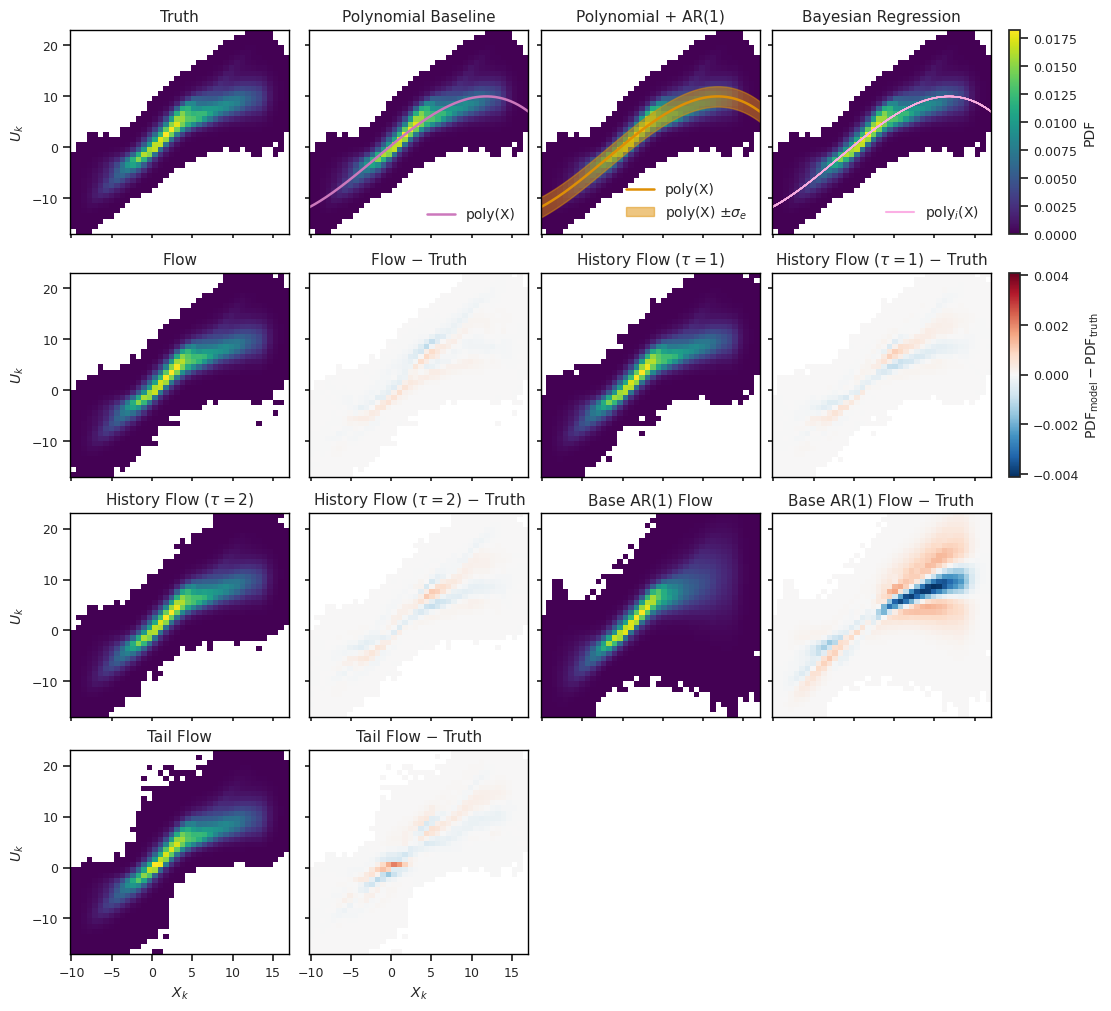

In [28]:
flows_to_plot = [
    ("parameters_flow", "default"),
    ("parameters_history_flow", "delta_t_1"),
    ("parameters_history_flow", "delta_t_2"),
    ("parameters_ar_base_flow", "default"),
    ("parameters_tail_flow", "default"),
]
show_contour_levels = False
fig = plot_parameter_fit_paper_ready_combined_four_columns(
    params_dict,
    x_test,
    u_test,
    u_sample_flow,
    bins=40,
    add_contours=show_contour_levels,
    contour_levels=4,
    flow_models_to_plot=flows_to_plot,
    figsize=(11, 10),
)

plt.show()

fig.savefig(
    paper_figures_dir / f"xu_fit_with_difference_{show_contour_levels}_2.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)
plt.close()
